100%|██████████| 6.84M/6.84M [00:00<00:00, 36.6MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adikurniawan/color-dataset-for-color-recognition/versions/1
Contents of dataset directory: ['training_dataset']
Checking images in /root/.cache/kagglehub/datasets/adikurniawan/color-dataset-for-color-recognition/versions/1...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 845ms/step - accuracy: 0.1427 - loss: 2.2280 - val_accuracy: 0.5800 - val_loss: 1.7643
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 389ms/step - accuracy: 0.3676 - loss: 1.7753 - val_accuracy: 0.7800 - val_loss: 0.9704
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - accuracy: 0.4929 - loss: 1.3039 - val_accuracy: 0.7600 - val_loss: 0.6766
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.6175 - loss: 0.9930 - val_accuracy: 0.8000 - val_loss: 0.5401
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.6428 - loss: 0.8721 - val_accuracy: 0.8000 - val_loss: 0.5749
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.7127 - loss: 0.7661 - val_accuracy: 0.9000 - val_loss: 0.2952
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.7436 - loss: 0.7328 - val_accuracy: 0.9000 - val_loss: 0.2831
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.8133 - loss: 0.4723 - val_accuracy: 0.8800 - 

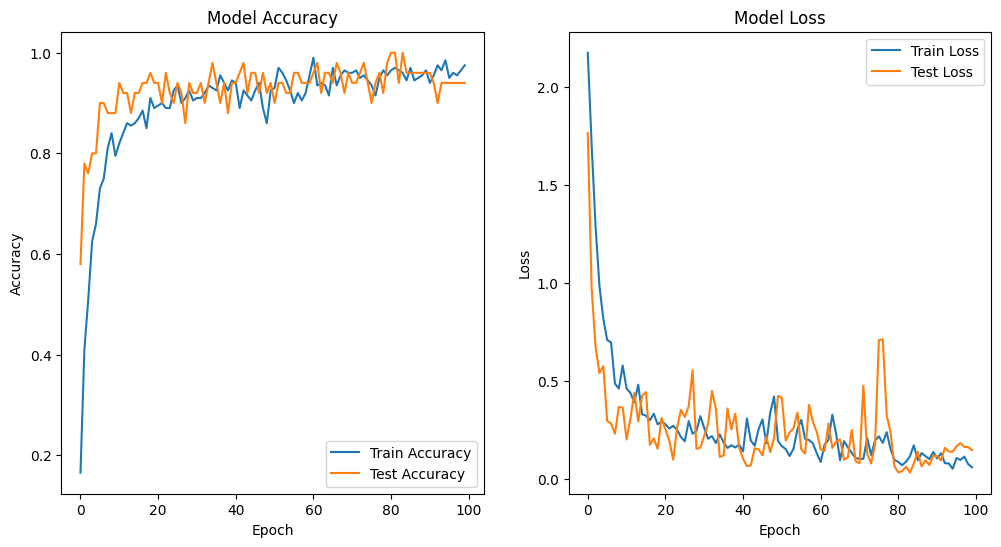

Saving Screenshot 2024-07-11 170746.png to Screenshot 2024-07-11 170746.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
The predicted color label for the image Screenshot 2024-07-11 170746.png is: white
Do you want to upload another image? (yes/no): no
Exiting the program.


In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
import kagglehub
from google.colab import files
import matplotlib.pyplot as plt

# Download dataset menggunakan kagglehub
path = kagglehub.dataset_download("adikurniawan/color-dataset-for-color-recognition")

# Debugging untuk memeriksa path dataset
print("Path to dataset files:", path)
print("Contents of dataset directory:", os.listdir(path))  # Periksa folder dataset

# Inisialisasi list untuk menampung data gambar dan label
images = []
labels = []

# Pastikan path mengarah ke folder yang berisi gambar
dataset_path = path  # Ubah ke path dataset yang valid
print(f"Checking images in {dataset_path}...")

# Loop melalui semua gambar dalam dataset
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)

        # Baca gambar dan konversi ke RGB
        image = cv2.imread(file_path)

        # Cek jika gambar tidak bisa dibaca
        if image is None:
            print(f"Skipping invalid or empty file: {file_path}")
            continue

        # Konversi gambar ke format RGB dan resize ke ukuran yang konsisten
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_resized = cv2.resize(image_rgb, (64, 64))  # Ubah ukuran gambar menjadi 64x64

        images.append(image_resized)
        labels.append(os.path.basename(dirname))  # Ambil nama folder sebagai label

# Konversi data menjadi numpy array
X = np.array(images)
y = np.array(labels)

# Normalisasi data gambar
X = X.astype('float32') / 255.0

# Encode label menjadi numerik
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split dataset untuk training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ubah dimensi data agar sesuai dengan input CNN (batch_size, height, width, channels)
X_train = X_train.reshape(-1, 64, 64, 3)
X_test = X_test.reshape(-1, 64, 64, 3)

# Bangun model CNN
model = Sequential()

# Layer Convolutional pertama
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer Convolutional kedua
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer Convolutional ketiga
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten untuk menyesuaikan input ke fully connected layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Dropout untuk menghindari overfitting

# Output layer
model.add(Dense(len(np.unique(y)), activation='softmax'))  # Softmax untuk klasifikasi multi-kelas

# Compile model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Latih model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# Evaluasi model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# Visualisasi hasil akurasi dan loss selama training
plt.figure(figsize=(12, 6))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step 
Classification Report:
              precision    recall  f1-score   support

       black       0.88      1.00      0.93         7
        blue       1.00      0.78      0.88         9
       brown       1.00      1.00      1.00         2
       green       0.83      1.00      0.91         5
        grey       1.00      1.00      1.00         2
      orange       1.00      0.67      0.80         3
         red       1.00      1.00      1.00         6
      violet       1.00      1.00      1.00         5
       white       1.00      1.00      1.00         3
      yellow       0.89      1.00      0.94         8

    accuracy                           0.94        50
   macro avg       0.96      0.94      0.95        50
weighted avg       0.95      0.94      0.94        50



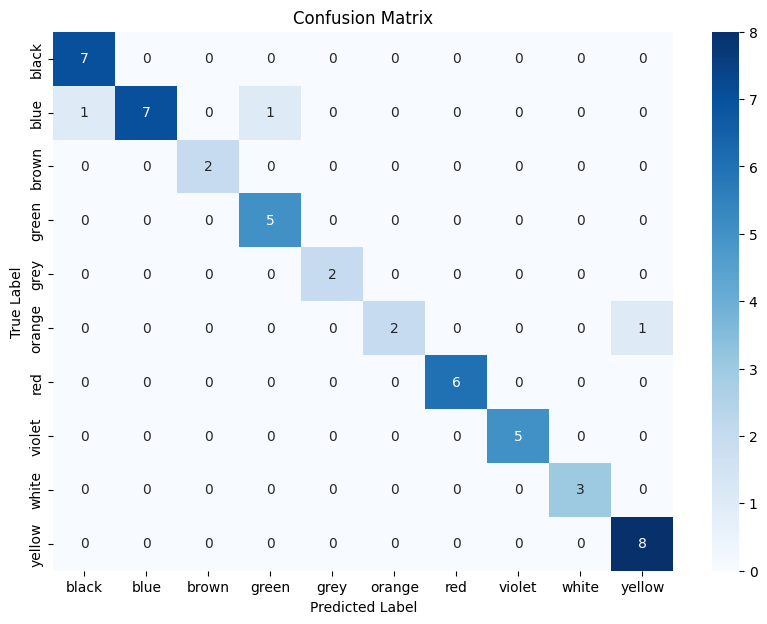

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Prediksi pada data uji
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # mengambil kelas dengan probabilitas tertinggi

# Menghitung precision, recall, dan f1-score
report = classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_)
print("Classification Report:")
print(report)

# Menghitung confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Fungsi untuk mengklasifikasikan gambar baru
def classify_new_image():
    while True:
        # Meminta pengguna untuk mengunggah gambar
        uploaded = files.upload()

        for filename in uploaded.keys():
            # Baca gambar baru dan konversi ke RGB
            image = cv2.imread(filename)
            if image is None:
                print(f"Error loading image: {filename}")
                return

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_resized = cv2.resize(image_rgb, (64, 64))  # Resize sesuai dengan input model
            image_resized = np.expand_dims(image_resized, axis=0)  # Menambahkan dimensi batch

            # Normalisasi gambar
            image_resized = image_resized.astype('float32') / 255.0

            # Prediksi menggunakan model CNN
            prediction = model.predict(image_resized)
            predicted_class = label_encoder.inverse_transform([np.argmax(prediction)])

            print(f"The predicted color label for the image {filename} is: {predicted_class[0]}")

        # Menanyakan apakah pengguna ingin mengunggah gambar lagi
        user_input = input("Do you want to upload another image? (yes/no): ").strip().lower()
        if user_input != 'yes':
            print("Exiting the program.")
            break

# Memanggil fungsi untuk mengklasifikasikan gambar baru
classify_new_image()


Saving Screenshot 2025-01-24 150119.png to Screenshot 2025-01-24 150119.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
The predicted color label for the image Screenshot 2025-01-24 150119.png is: white
Do you want to upload another image? (yes/no): yes


Saving desktop-wallpaper-blackberry-sorbet-color.png to desktop-wallpaper-blackberry-sorbet-color.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
The predicted color label for the image desktop-wallpaper-blackberry-sorbet-color.png is: violet
Do you want to upload another image? (yes/no): yes


Saving colorpic.jpg to colorpic.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
The predicted color label for the image colorpic.jpg is: grey
Do you want to upload another image? (yes/no): yes


Saving th.jpg to th.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
The predicted color label for the image th.jpg is: red
Do you want to upload another image? (yes/no): yes


Saving th (1).jpg to th (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
The predicted color label for the image th (1).jpg is: white
Do you want to upload another image? (yes/no): no
Exiting the program.
